# 01. Data Prep and Stylized Facts

This notebook builds the clean daily dataset that will be reused in the rest of the project. The economic logic is simple: before testing whether the structure of risk changed after COVID-19, we first need a clean and well-understood set of transformed series. We therefore load the 14 market variables, transform them in a way that is consistent with their financial nature, document their stylized facts, and justify the COVID break date with variance break tests on the S&P 500.

## 1. Setup

We keep the notebook light and readable by importing only the packages needed for the descriptive stage. The reusable functions are stored in `src/project2_data_utils.py` so that later notebooks can rely on exactly the same cleaned inputs and break definition.

In [1]:
from _notebook_setup import bootstrap_notebook

bootstrap_notebook()

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from project2_config import (
    ANALYSIS_START,
    COVID_BREAK,
    PRICE_COLUMNS,
    YIELD_COLUMNS,
    DISPLAY_NAMES,
)
from project2_data_utils import (
    ensure_output_dirs,
    load_raw_data,
    build_aligned_returns,
    split_pre_post,
    build_stylized_facts_table,
    variance_chow_test,
    quandt_andrews_style_variance_test,
    bai_perron_style_breaks,
    plot_level_panel,
    plot_correlation_heatmaps,
    plot_acf_grid,
    plot_variance_breaks,
    save_dataframe,
    save_figure,
)

ensure_output_dirs()

## 2. Load the workbook and inspect the raw series

We first load the Excel file exactly as provided. At this stage we do not transform anything yet: the point is to verify the raw date range, the number of columns and the amount of missing data before making any modelling choice.

In [2]:
raw_data = load_raw_data()

print(f"Raw dataset shape: {raw_data.shape}")
print(f"Raw date range: {raw_data['date'].min().date()} to {raw_data['date'].max().date()}")
raw_data.head()

Raw dataset shape: (9601, 15)
Raw date range: 1989-12-31 to 2026-04-24


,date,sp500,eurostoxx50,hang_seng,msci_em,smi,ust10y_yield,bund10y_yield,oil,gold,eurusd,usdjpy,us_ig_bonds,us_hy_bonds,usdchf
0,1989-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,447.9810,182.3050,NaN
1,1990-01-01,NaN,1098.4900,NaN,214.6900,NaN,NaN,NaN,NaN,NaN,NaN,143.8000,NaN,NaN,1.5410
2,1990-01-02,359.6900,1101.3400,2838.0701,217.3000,NaN,7.9300,7.4840,22.8900,399.0000,1.2146,146.2500,447.9210,182.4720,1.5768
3,1990-01-03,358.7600,1112.8199,2858.7200,220.4500,1824.0000,7.9740,7.5070,23.6800,395.0000,1.2096,145.7000,447.4050,182.5910,1.5785
4,1990-01-04,355.6700,1113.0200,2867.9500,227.3000,1824.5000,7.9720,7.4280,23.4100,396.5000,1.2287,143.3700,447.3250,182.9350,1.5420


In [3]:
missing_summary = (
    raw_data.isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .to_frame()
    .assign(first_valid=lambda df: [raw_data[col].first_valid_index() for col in df.index])
)
missing_summary

,missing_pct,first_valid
date,0.0000,0
sp500,4.7495,2
eurostoxx50,2.6664,1
hang_seng,6.6660,2
msci_em,1.3124,1
smi,4.9474,3
ust10y_yield,5.4578,2
bund10y_yield,4.0829,2
oil,7.0722,2
gold,1.9269,2


## 3. Transform the raw series into analysis variables

The transformation follows standard financial econometrics and the course instructions:

- price and index series are converted into **daily log returns in percent**;
- **except oil**, where we use a simple percentage return because the April 2020 negative WTI settlement makes a log return undefined;
- yield series are converted into **first differences in basis points**.

This distinction matters economically. Prices scale multiplicatively, which is why log returns are natural. Yields are already rates, so taking log returns would be meaningless. We therefore use changes in basis points for the US and German 10-year yields. Oil is the only deliberate exception, because the negative WTI print in April 2020 would otherwise break the return calculation exactly in the crisis window that matters for this project.

We then apply an **aligned drop of missing values** so that all subsequent comparisons use exactly the same daily sample across assets.

In [4]:
level_data, aligned_returns = build_aligned_returns(raw_data)
pre_covid, post_covid = split_pre_post(aligned_returns)

print(f"Aligned return sample starts on: {aligned_returns['date'].min().date()}")
print(f"Aligned return sample ends on:   {aligned_returns['date'].max().date()}")
print(f"Aligned return dataset shape:    {aligned_returns.shape}")
print(f"Pre-COVID sample shape:         {pre_covid.shape}")
print(f"Post-COVID sample shape:        {post_covid.shape}")

aligned_returns.head()

Aligned return sample starts on: 2000-01-05
Aligned return sample ends on:   2026-04-24
Aligned return dataset shape:    (5579, 15)
Pre-COVID sample shape:         (4251, 15)
Post-COVID sample shape:        (1328, 15)


C:\Users\loren\emif-project-2-risk-structure-after-covid\src\project2_data_utils.py:72: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  transformed_data[column] = 100.0 * level_data[column].pct_change()


,date,sp500,eurostoxx50,hang_seng,msci_em,smi,oil,gold,eurusd,usdjpy,us_ig_bonds,us_hy_bonds,usdchf,ust10y_yield,bund10y_yield
0,2000-01-05,0.1920,-2.5237,-7.4525,-1.8740,-1.2015,-2.5049,-0.8004,0.2425,0.8874,-0.5194,-0.1859,-0.5602,9.7000,2.3600
1,2000-01-06,0.0955,-0.9082,-4.4749,-1.0336,1.3733,-0.5219,0.3921,0.0678,1.0412,0.3104,0.0338,0.2966,-7.0000,2.9200
2,2000-01-07,2.6730,3.2264,1.6519,1.2391,2.2732,-2.2599,0.2310,-0.3200,0.1045,0.1460,-0.0160,0.7313,-0.9000,-10.1400
3,2000-01-10,1.1128,1.4048,2.8320,2.9217,0.0644,1.8580,-0.0959,-0.3795,-0.1710,-0.0867,0.0534,0.3063,3.7000,-2.8700
4,2000-01-11,-1.3149,-0.9063,0.0880,-1.7058,-0.4397,4.4589,0.6269,0.7770,0.7484,-0.4046,-0.0870,-0.7098,10.5000,12.5900


In [5]:
transformation_table = pd.DataFrame({
    "asset": PRICE_COLUMNS + YIELD_COLUMNS,
    "display_name": [DISPLAY_NAMES[col] for col in PRICE_COLUMNS + YIELD_COLUMNS],
    "transformation": [
        "log return (%)" if col != "oil" else "simple return (%)" for col in PRICE_COLUMNS
    ] + ["first difference (bp)"] * len(YIELD_COLUMNS),
})
transformation_table

,asset,display_name,transformation
0,sp500,S&P 500,log return (%)
1,eurostoxx50,Euro Stoxx 50,log return (%)
2,hang_seng,Hang Seng,log return (%)
3,msci_em,MSCI EM,log return (%)
4,smi,SMI,log return (%)
5,oil,Oil futures,simple return (%)
6,gold,Gold,log return (%)
7,eurusd,EURUSD,log return (%)
8,usdjpy,USDJPY,log return (%)
9,us_ig_bonds,US IG bonds,log return (%)


## 4. Visual inspection of the main raw market series

Before going to returns, we keep a quick look at raw levels. This is useful because structural breaks often appear first as changes in trend, volatility or co-movement in the underlying market levels. We focus on four anchor markets that will remain central later in the project: equities, oil, gold and credit.

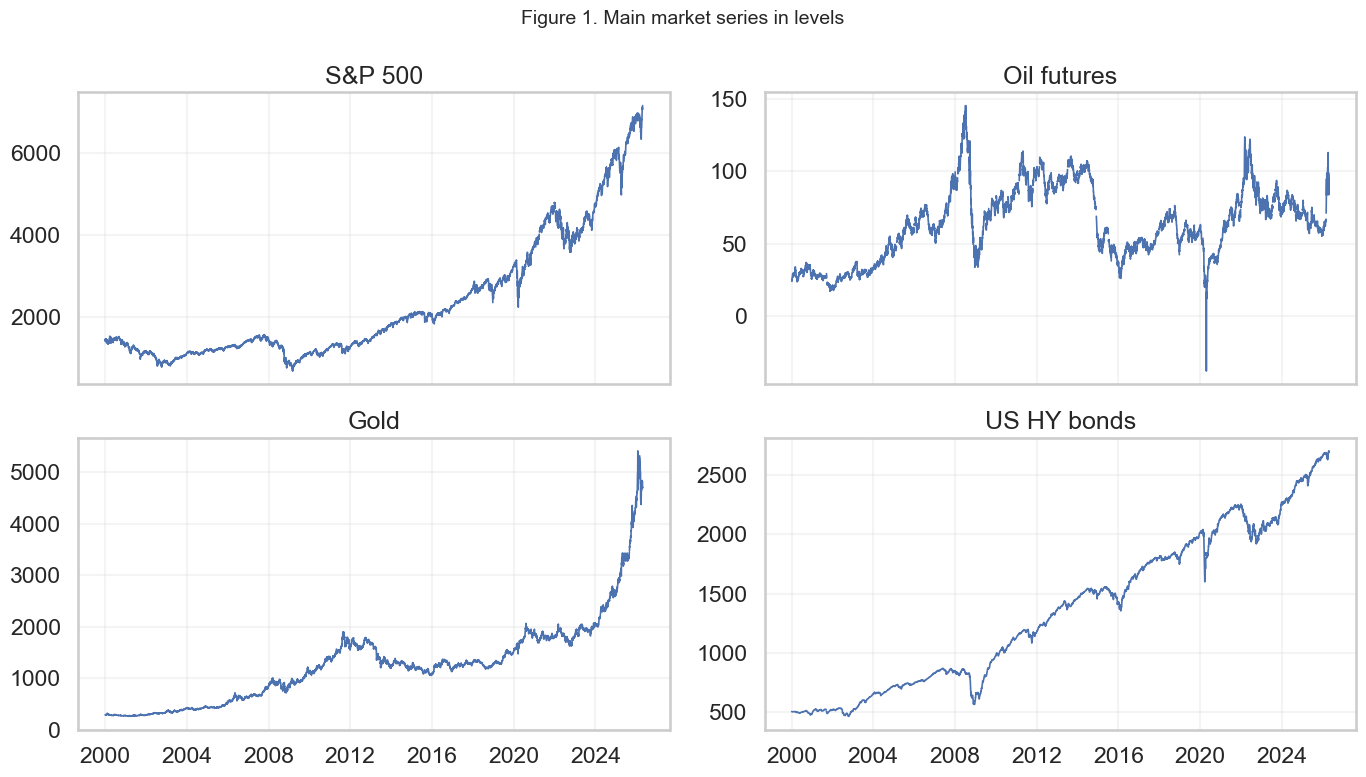

In [6]:
level_figure = plot_level_panel(
    level_data.loc[level_data['date'] >= pd.Timestamp(ANALYSIS_START)],
    columns=["sp500", "oil", "gold", "us_hy_bonds"],
    title="Figure 1. Main market series in levels",
)
save_figure(level_figure, "01_level_panel.png")
plt.show()

## 5. Stylized facts before and after COVID

We now compute descriptive moments and downside risk measures separately before and after the COVID break. The goal is to see whether the distribution of daily risk changes across samples, not only whether average returns move.

The table includes:
- mean and standard deviation;
- skewness and excess kurtosis;
- Jarque-Bera and Anderson-Darling normality tests;
- 5% Value-at-Risk and Expected Shortfall;
- maximum drawdown for price-based assets.

For yield changes, maximum drawdown is left blank because drawdown is economically meaningful for cumulative wealth processes, not for daily basis-point changes.

In [7]:
stylized_facts = build_stylized_facts_table(pre_covid, post_covid)
save_dataframe(stylized_facts, "01_stylized_facts_pre_post.csv")
stylized_facts

,sample,asset,n_obs,mean_daily,std_daily,skewness,excess_kurtosis,jarque_bera_stat,jarque_bera_pvalue,anderson_darling_stat,anderson_darling_pvalue,var_5pct,es_5pct,max_drawdown,asset_label
0,Pre-COVID,sp500,4251,0.0180,1.1720,-0.2639,7.5026,9992.3140,0.0000,inf,0.0000,-1.8699,-2.8635,-0.6346,S&P 500
1,Pre-COVID,eurostoxx50,4251,0.0026,1.4180,-0.0423,4.5604,3674.0531,0.0000,47.2075,0.0000,-2.2866,-3.3686,-0.6904,Euro Stoxx 50
2,Pre-COVID,hang_seng,4251,0.0034,1.4240,-0.0202,8.5447,12897.7208,0.0000,inf,0.0000,-2.2645,-3.3594,-0.6015,Hang Seng
3,Pre-COVID,msci_em,4251,0.0193,1.1728,-0.4595,8.0788,11678.7395,0.0000,inf,0.0000,-1.8550,-2.8181,-0.5660,MSCI EM
4,Pre-COVID,smi,4251,0.0069,1.1172,-0.2924,6.0023,6423.8252,0.0000,50.4527,0.0000,-1.7417,-2.7163,-0.5132,SMI
5,Pre-COVID,oil,4251,0.0776,2.3431,0.1183,5.0080,4439.2517,0.0000,30.5806,0.0000,-3.5739,-5.2262,-0.6716,Oil futures
6,Pre-COVID,gold,4251,0.0245,1.0671,-0.2999,6.7945,8218.0651,0.0000,inf,0.0000,-1.6672,-2.5372,-0.4541,Gold
7,Pre-COVID,eurusd,4251,0.0088,0.6118,0.0650,1.6517,484.2253,0.0000,14.6810,0.0000,-0.9915,-1.3660,-0.2258,EURUSD
8,Pre-COVID,usdjpy,4251,0.0012,0.6269,-0.0654,4.1440,3035.5081,0.0000,inf,0.0000,-0.9860,-1.4489,-0.4423,USDJPY
9,Pre-COVID,us_ig_bonds,4251,0.0231,0.2985,-0.3515,2.4274,1127.5041,0.0000,12.7505,0.0000,-0.4815,-0.6820,-0.1231,US IG bonds


## 6. Correlation structure before and after COVID

The project asks whether the **structure of risk** changed, not just the volatility of each asset. The first natural check is therefore the correlation matrix. We compare the full cross-asset dependence pattern before and after the COVID break.

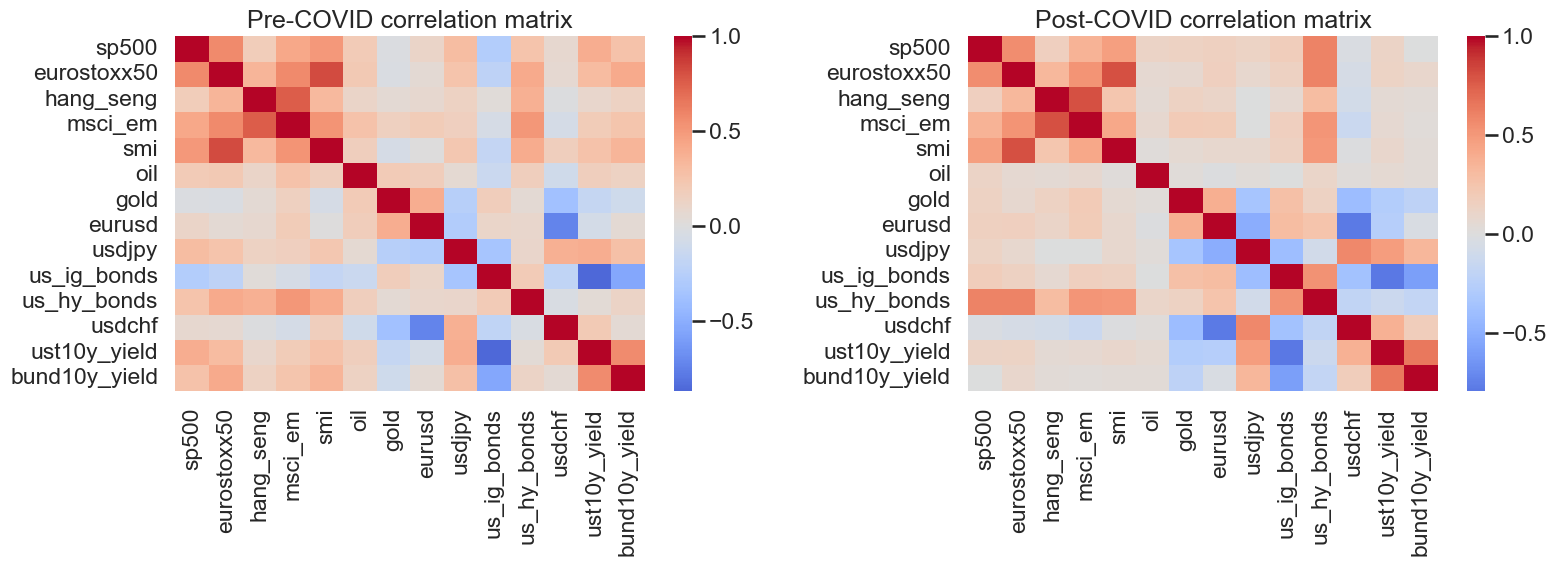

In [8]:
correlation_figure = plot_correlation_heatmaps(pre_covid, post_covid)
save_figure(correlation_figure, "01_pre_post_correlation_heatmaps.png")
plt.show()

## 7. Autocorrelograms and volatility clustering

Autocorrelograms are useful here for two reasons. First, they reveal whether raw returns are close to serially uncorrelated, which is typical for liquid markets. Second, they help us see whether **volatility clustering** is present, which will motivate the GARCH models in the next notebook.

We therefore plot the ACF of raw transformed series, and then the ACF of squared series as a simple variance proxy.

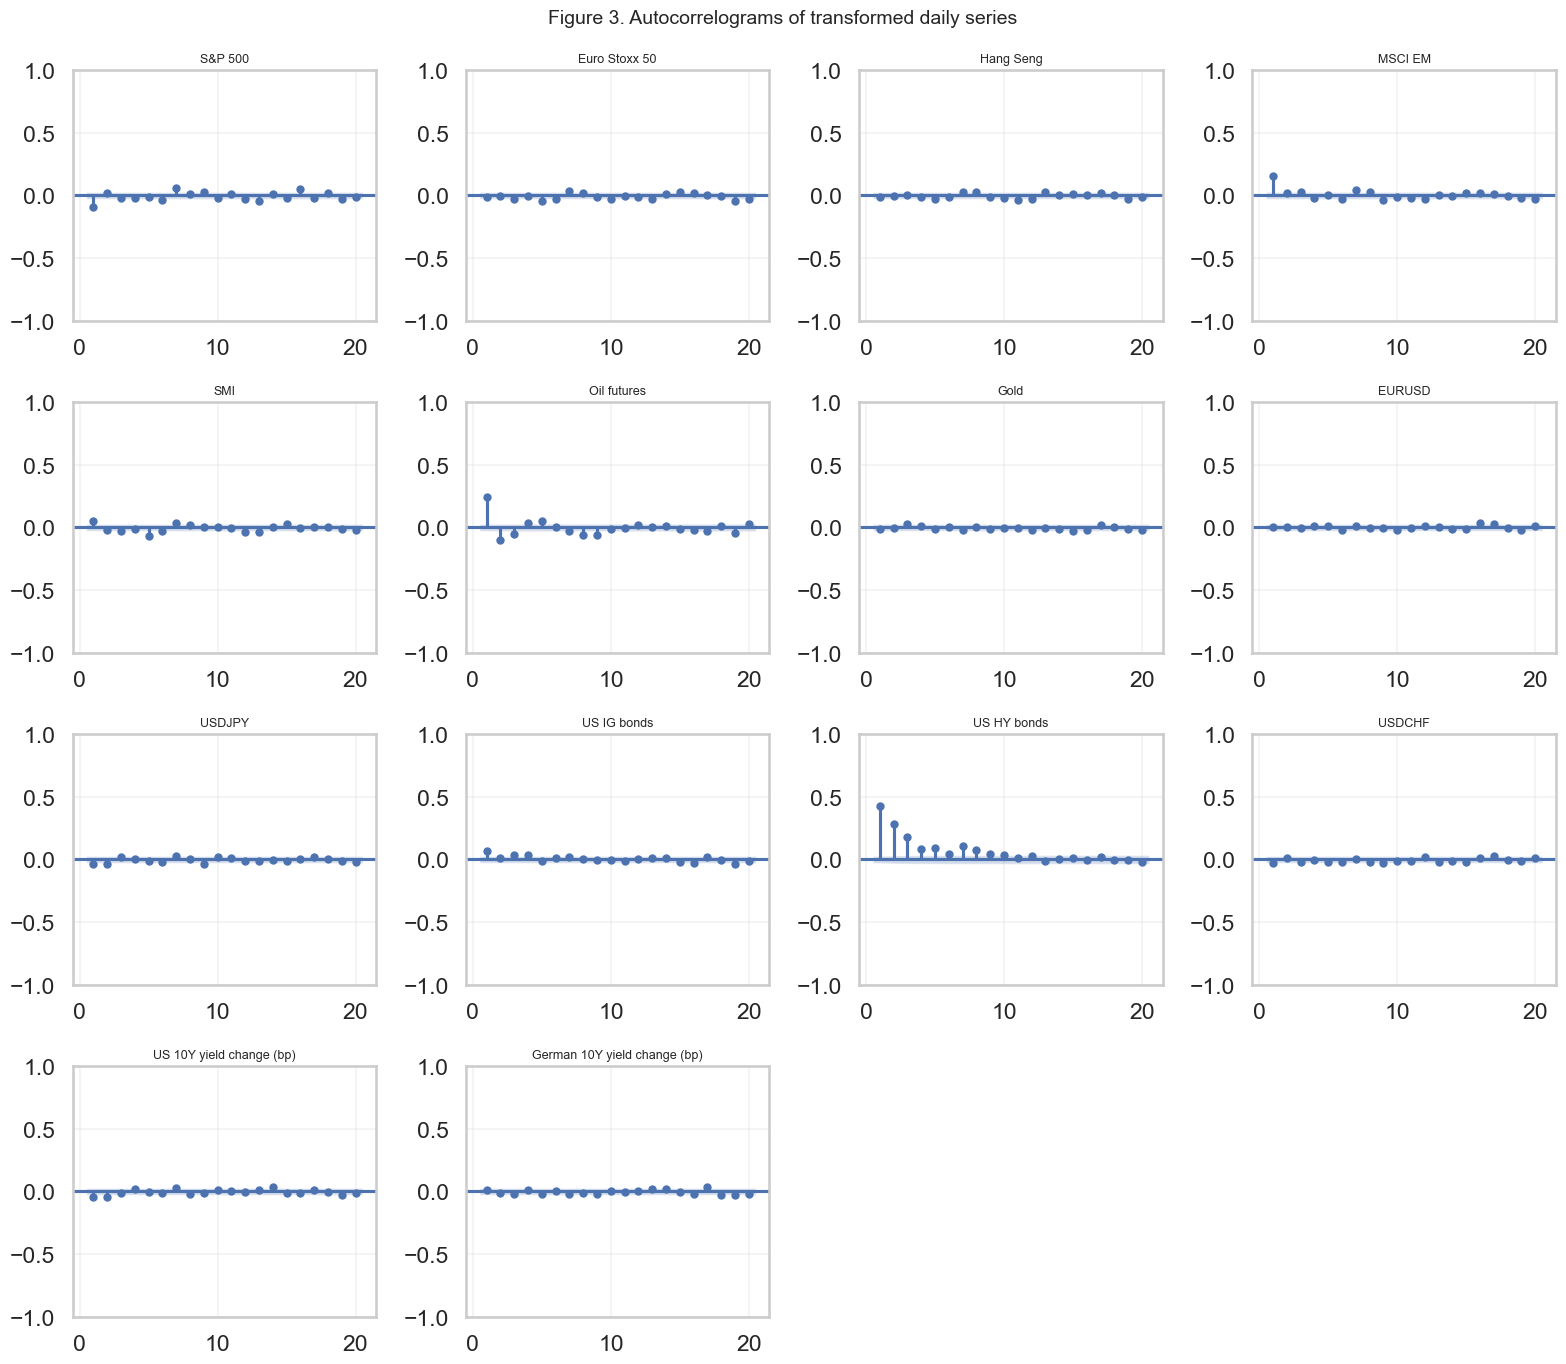

In [9]:
acf_returns_figure = plot_acf_grid(aligned_returns, "Figure 3. Autocorrelograms of transformed daily series", squared=False)
save_figure(acf_returns_figure, "01_return_acf_grid.png")
plt.show()

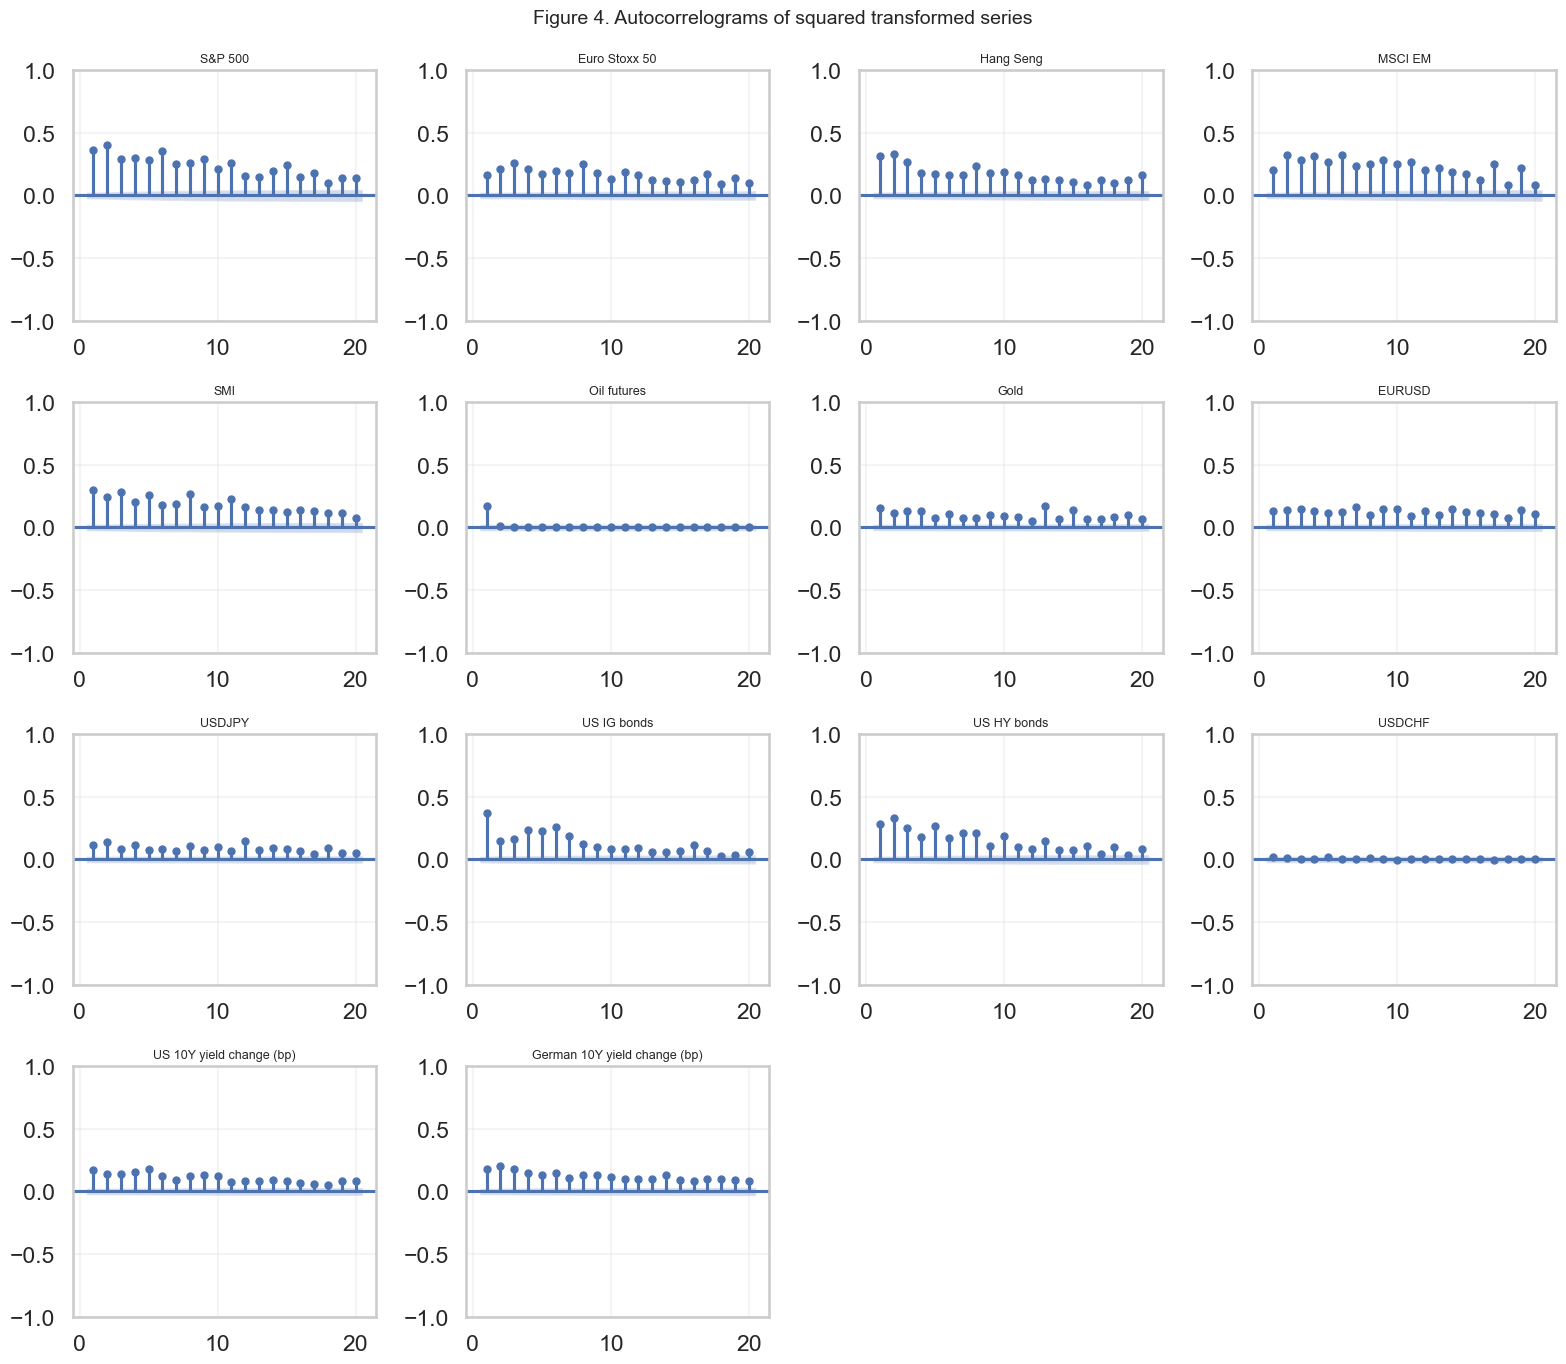

In [10]:
acf_squared_figure = plot_acf_grid(aligned_returns, "Figure 4. Autocorrelograms of squared transformed series", squared=True)
save_figure(acf_squared_figure, "01_squared_return_acf_grid.png")
plt.show()

## 8. Why use 11 March 2020 as the COVID break?

The economic break date is fixed at **11 March 2020**, the day the WHO declared COVID-19 a global pandemic. Because the project should not rely on a purely narrative choice, we also check whether the S&P 500 variance proxy displays a statistically meaningful break around that date.

We use two complementary tests on **squared S&P 500 returns**, which act as a daily proxy for variance:
- a **Chow-style variance break test** imposed at 11 March 2020;
- a **Quandt-Andrews style sup-F scan** over many possible break dates;
- a **Bai-Perron style multiple-break search** implemented with `ruptures`.

In [11]:
sp500_variance_proxy = pd.concat([pre_covid[["date", "sp500"]], post_covid[["date", "sp500"]]], ignore_index=True).set_index("date")["sp500"] ** 2

covid_break_test = variance_chow_test(sp500_variance_proxy, COVID_BREAK)
quandt_table = quandt_andrews_style_variance_test(sp500_variance_proxy)
multiple_breaks = bai_perron_style_breaks(sp500_variance_proxy, n_breaks=3, min_size=63)

covid_break_table = pd.DataFrame([covid_break_test])
quandt_top5 = quandt_table.head(5)

save_dataframe(covid_break_table, "01_chow_variance_break_at_covid.csv")
save_dataframe(quandt_table, "01_quandt_andrews_variance_scan.csv")
save_dataframe(multiple_breaks, "01_bai_perron_variance_breaks.csv")

covid_break_table

,break_date,f_stat,p_value,pre_variance_mean,post_variance_mean,n_pre,n_post
0,2020-03-11,2.9898,0.0838,1.4033,1.6877,4290,1289


In [12]:
print("Top 5 Quandt-Andrews style break candidates on S&P 500 variance proxy")
quandt_top5

Top 5 Quandt-Andrews style break candidates on S&P 500 variance proxy


,break_date,f_stat,p_value_chow_style
0,2011-12-21,26.1150,0.0000
1,2011-12-22,26.0370,0.0000
2,2011-12-01,26.0044,0.0000
3,2011-12-23,25.9932,0.0000
4,2011-12-29,25.9565,0.0000


In [13]:
print("Bai-Perron style multiple breaks on S&P 500 variance proxy")
multiple_breaks

Bai-Perron style multiple breaks on S&P 500 variance proxy


,break_index,break_date
0,1845,2008-08-28
1,1910,2008-12-18
2,2555,2011-12-22


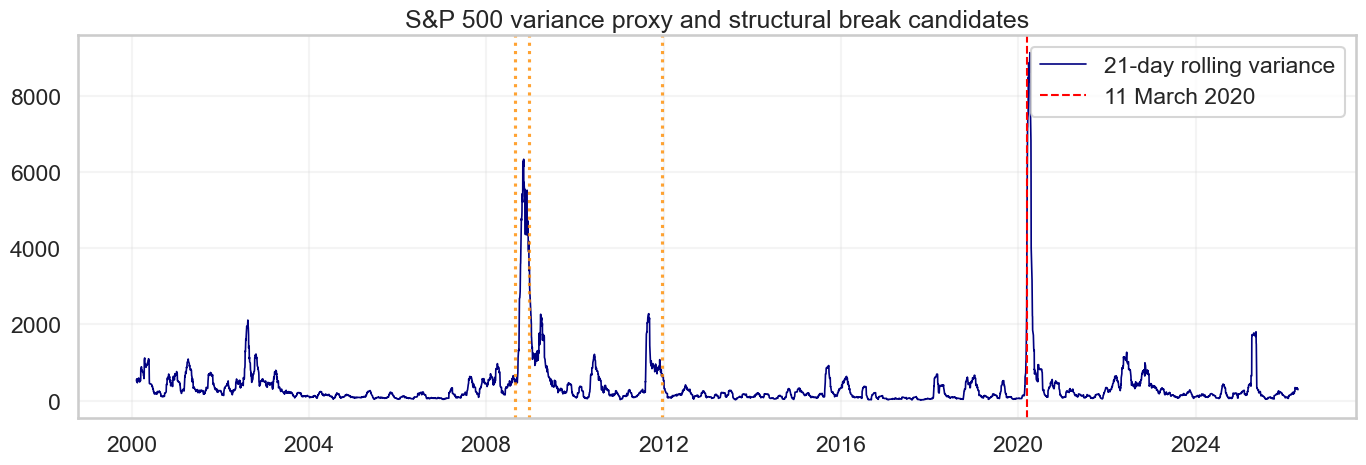

In [14]:
break_figure = plot_variance_breaks(
    sp500_returns=aligned_returns.set_index('date')['sp500'],
    covid_break=COVID_BREAK,
    break_table=multiple_breaks,
)
save_figure(break_figure, "01_sp500_variance_breaks.png")
plt.show()

## 9. Save the cleaned dataset for the next notebooks

A modular project becomes much easier to maintain when every later notebook starts from the same transformed dataset. We therefore save the aligned return matrix and the two sub-samples to `outputs/project2/tables/`.

In [15]:
save_dataframe(aligned_returns, "01_aligned_returns.csv")
save_dataframe(pre_covid, "01_pre_covid_returns.csv")
save_dataframe(post_covid, "01_post_covid_returns.csv")

print("Saved cleaned data and tables under outputs/project2/")

Saved cleaned data and tables under outputs/project2/


## 10. Main takeaways from notebook 01

At this stage, we have a clean daily panel, a disciplined pre/post split, and a first statistical justification for the COVID break date. We also know whether the post-COVID period differs in terms of tail risk, cross-asset dependence and volatility clustering. This provides the exact empirical base needed for the volatility models, DCC analysis, VAR and regime analysis in the next notebooks.